## 3. 探索目的による分類

| 探索の観点 | 単変量 | 多変量 |
|---|:---:|:---:|
| 分布 | ✅ | ✅ |
| 比較 | ✅ | ✅ |
| 関係 | ❌ | ✅ |
| 時間 | △ | ✅ |
| 空間 | △ | ✅ |

#### `① 比較の可視化`

**「何がより大きいか？」**

**「グループ間に違いがあるか？」**


#### ※ 主なグラフ

- 棒グラフ
- グループ化棒グラフ
- 積み上げ棒グラフ
- 100%積み上げ棒グラフ
- Boxplot

<div style="
    background-color:#232627;
    padding:14px 0;
    margin:14px 0;
    font-family:'Yu Gothic', sans-serif;
    font-size:15px;
    line-height:1.6;
    width:100%;
">

<div style="background-color:#2b2e2f; padding:6px 20px;">
地域別売上
</div>

<div style="background-color:#232627; height:22px;"></div>

<div style="background-color:#2b2e2f; padding:6px 20px;">
東京
<span style="
    display:inline-block;
    width:130px;
    height:16px;
    background-color:#f5f5f5;
    margin-left:18px;
    vertical-align:middle;
"></span>
</div>

<div style="background-color:#232627; padding:6px 20px;">
大阪
<span style="
    display:inline-block;
    width:85px;
    height:16px;
    background-color:#f5f5f5;
    margin-left:18px;
    vertical-align:middle;
"></span>
</div>

<div style="background-color:#2b2e2f; padding:6px 20px;">
名古屋
<span style="
    display:inline-block;
    width:55px;
    height:16px;
    background-color:#f5f5f5;
    margin-left:4px;
    vertical-align:middle;
"></span>
</div>

</div>

#### 【実習】

#### 実習環境の設定

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# グラフで日本語が文字化けしないようにフォントを変更
plt.rcParams["font.family"] = "Yu Gothic"

# グラフで「-」記号が文字化けするのを防止
plt.rcParams["axes.unicode_minus"] = False

#### - `グループ化棒グラフ`

**性別 × 試験 → 平均点を比較**


#### - `積み上げ棒グラフ`

**性別 × クラス → 学生の構成を比較**


#### - `カテゴリ別Boxplot`

**性別 × 点数 → グループごとの分布を比較**

<br>

#### 2) グループ化棒グラフ

性別・試験の平均データから、  
**男性と女性の中間試験・期末試験の平均点を並べて比較する。**

In [17]:
df = pd.DataFrame({
    "名前": ["ハク", "千尋", "アシタカ", "サン"],
    "性別": ["男", "女", "男", "女"],
    "中間試験": [78, 82, 85, 90],
    "期末試験": [84, 88, 80, 92]
})

df

,名前,性別,中間試験,期末試験
0,ハク,男,78,84
1,千尋,女,82,88
2,アシタカ,男,85,80
3,サン,女,90,92


In [19]:
# 前処理
result = df.groupby("性別")[["中間試験", "期末試験"]].mean()

result

,中間試験,期末試験
性別,,
女,86.0,90.0
男,81.5,82.0


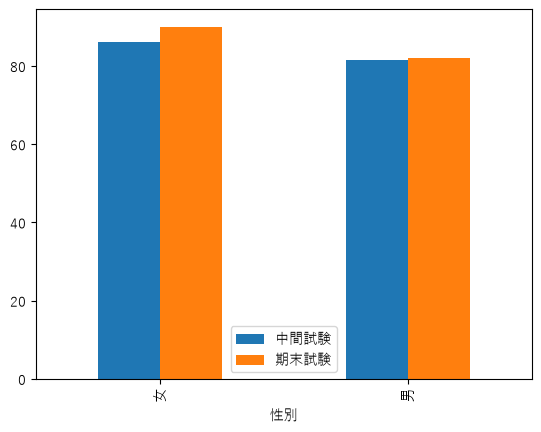

In [20]:
# stacked=False は省略してもグループ化棒グラフになる
# stacked=True にすると積み上げ棒グラフになる
result.plot(kind="bar", stacked=False);

それぞれ次のように対応する。

| **グラフ要素** | **自動的に決定される基準** |
|---|---|
| X軸 | `result` のインデックス → 性別 |
| Y軸 | 列の数値 → 平均点 |
| 棒グループ | インデックスの値 → 男、女 |
| 各グループの棒 | `result` の列 → 中間試験、期末試験 |

#### 2) 積み上げ棒グラフ

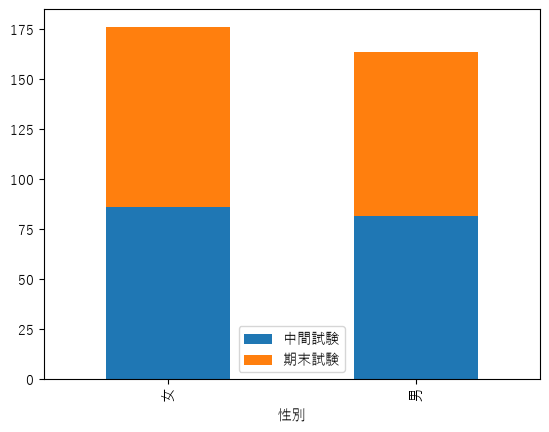

In [21]:
result.plot(kind="bar", stacked=True);

#### 3) Boxplot

Boxplotの場合、元のデータをそのまま使用できる。

1つのBoxplotは分布の確認に使用されるが、2つ以上使用すると複数の分布を比較できる。

In [10]:
# --------------------------------------------------
# 学生成績データを作成
# --------------------------------------------------

data = {
    "名前": [
        "千尋", "ハク", "アシタカ", "サン", "ハウル",
        "ソフィー", "パズー", "シータ", "キキ", "トンボ",
        "ポルコ", "フィオ", "宗介", "ポニョ", "アリエッティ",
        "翔", "清太", "節子", "月島雫", "天沢聖司",
        "松崎海", "風間俊", "ナウシカ", "アスベル", "サツキ",
        "メイ", "杏奈", "マーニー", "菜穂子", "二郎"
    ],

    "性別": [
        "男", "女", "男", "女", "男",
        "男", "女", "男", "女", "女",
        "男", "女", "男", "女", "男",
        "女", "男", "女", "男", "女",
        "男", "女", "男", "女", "男",
        "女", "男", "女", "男", "女"
    ],

    "クラス": [
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B",
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B",
        "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B"
    ],

    "学年": [
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        2, 2, 2, 2, 2,
        2, 2, 2, 2, 2,
        3, 3, 3, 3, 3,
        3, 3, 3, 3, 3
    ],

    "中間試験": [
        70, 82, 65, 90, 75,
        88, 72, 80, 95, 68,
        78, 85, 70, 92, 81,
        75, 89, 94, 73, 86,
        83, 91, 77, 96, 72,
        88, 79, 93, 85, 90
    ],

    "期末試験": [
        75, 85, 70, 88, 78,
        92, 76, 84, 97, 73,
        82, 88, 75, 95, 85,
        80, 91, 96, 78, 90,
        87, 94, 81, 98, 76,
        92, 83, 95, 89, 93
    ]
}

df = pd.DataFrame(data)

# データを確認
display(df.head())

# 行数と列数を確認
print(df.shape)

,名前,性別,クラス,学年,中間試験,期末試験
0,千尋,男,A,1,70,75
1,ハク,女,A,1,82,85
2,アシタカ,男,A,1,65,70
3,サン,女,A,1,90,88
4,ハウル,男,A,1,75,78


(30, 6)


#### **1) 1つの数値型変数をカテゴリ型変数でグループ化して比較**

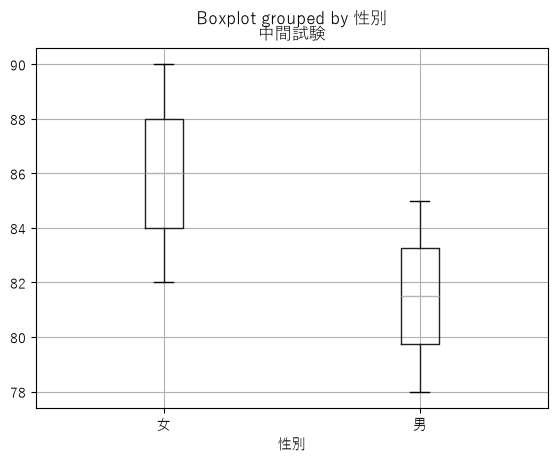

In [22]:
# ------------------------------------------
# 男女学生の中間試験の点数分布を比較
# ------------------------------------------

# df.plot(kind="box", by="性別", column="中間試験")

# デフォルト値に違いはあるが、ほぼ同じ表現
# plot() はより抽象化されたメソッド
df.boxplot(by="性別", column="中間試験");

#### **2) 2つの数値型変数を比較**

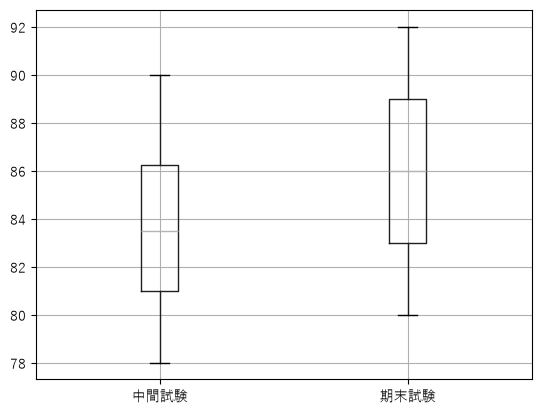

In [24]:
df.boxplot(column=["中間試験", "期末試験"]);